## mlp continuum robot playground

### data handling

In [156]:
import pandas as pd
import matplotlib.pyplot as plt

# csv & dropna & start point 0
mt_data = pd.read_csv('motor_telemetry.csv')
sr_data = pd.read_csv('softrobot.csv', skiprows=6)

mt_data = mt_data.dropna()
sr_data = sr_data.dropna()

print(sr_data.shape)
for i in range(1, 5):
    mt_data.iloc[:,i] -= mt_data.iloc[0, i]
for i in range(2, 11):
    sr_data.iloc[:,i] -= sr_data.iloc[0, i]


# fig, ax = plt.subplots(5,1, figsize=(10, 15))
# ax[0].plot(mt_data['Time'][:10000], mt_data['Motor_0'][:10000], label='Motor Speed', color='blue')
# ax[0].set_title('Motor0 Speed vs Time')
# ax[1].plot(mt_data['Time'][:10000], mt_data['Motor_1'][:10000], label='Motor Speed', color='blue')
# ax[1].set_title('Motor1 Speed vs Time')
# ax[2].plot(mt_data['Time'][:10000], mt_data['Motor_2'][:10000], label='Motor Speed', color='blue')
# ax[2].set_title('Motor2 Speed vs Time')
# ax[3].plot(mt_data['Time'][:10000], mt_data['Motor_3'][:10000], label='Motor Speed', color='blue')
# ax[3].set_title('Motor3 Speed vs Time')
# ax[4].plot(sr_data['Time'][:10000], sr_data['X'][:10000], label='X', color='orange')
# ax[4].plot(sr_data['Time'][:10000], sr_data['Y'][:10000], label='Y', color='purple')
# ax[4].plot(sr_data['Time'][:10000], sr_data['Z'][:10000], label='Z', color='yellow')
# ax[4].set_title('XYZ1vs Time')
# plt.tight_layout()
# plt.show()


(31343, 11)


In [157]:
import numpy as np

# interpolation
interp_list = []
for i in range(4):
    interp_list.append(np.interp(sr_data['Time'].values, mt_data['Time'].values, mt_data.iloc[:, i+1].values))

# fig,ax = plt.subplots(2,1, figsize=(6, 8))
# ax[0].plot(interp_list[0][1000:2000], label='Interp Speed', color='blue')
# ax[1].plot(mt_data['Motor_0'][500:2000], label ='Speed', color='orange')
# ax[0].set_title('Motor0 Speed vs Time')
# plt.legend()
# plt.show()


In [165]:

# x_all = np.column_stack(tuple([i for i in sr_data.iloc[:, 2:].values])).transpose()

# P1 = x_all[1:,:3]
# P2 = x_all[1:,3:6]
# P3 = x_all[1:,6:9]

# v1 = P2-P1
# v2 = P3-P1

# z_axis = np.cross(v1, v2)
# z_unit = z_axis / np.linalg.norm(z_axis, axis=1, keepdims=True)

# x_axis = P3-(P1 + P2)/2
# x_unit = x_axis / np.linalg.norm(x_axis, axis=1, keepdims=True)

# y_unit = np.cross(z_unit, x_unit)

# rot_matrix = np.stack((x_unit,y_unit, z_unit), axis=-1)

# print(rot_matrix.shape)

# roll = np.arctan2(rot_matrix[:, 2, 1], rot_matrix[:, 2, 2])
# pitch = np.arctan2(-rot_matrix[:, 2, 0], np.sqrt(rot_matrix[:, 2, 1]**2 + rot_matrix[:, 2, 2]**2))
# yaw = np.arctan2(rot_matrix[:, 1, 0], rot_matrix[:, 0, 0])

# rpy_data = np.column_stack(tuple([np.rad2deg(roll), np.rad2deg(pitch), np.rad2deg(yaw)]))

# import sys; sys.exit()
# add roll pitch yaw? + 1 point + prev points?

# prev points
x_raw = np.column_stack(tuple([i for i in sr_data.iloc[:, 2:].values])).transpose() 

lags = 3
t_prevs = np.array([x_raw[lags - i : len(x_raw) - i] for i in range(lags + 1)])
for i in range(1,len(t_prevs)):
    t_prevs[i] = t_prevs[0] - t_prevs[i]
X = np.hstack(t_prevs)
Y = np.column_stack(tuple(interp_list))[lags:]
print(X.shape, Y.shape)




(31340, 36) (31340, 4)


In [193]:
def rpy(p1, p2, p3):
    v1 = p2-p1
    v2 = p3-p1

    z_axis = np.cross(v1, v2)
    z_unit = z_axis / np.linalg.norm(z_axis, axis=1, keepdims=True)

    x_axis = p3-(p1 + p2)/2
    x_unit = x_axis / np.linalg.norm(x_axis, axis=1, keepdims=True)

    y_unit = np.cross(z_unit, x_unit)
    rot_matrix = np.stack((x_unit,y_unit, z_unit), axis=-1)

    roll = np.arctan2(rot_matrix[:, 2, 1], rot_matrix[:, 2, 2])
    pitch = np.arctan2(-rot_matrix[:, 2, 0], np.sqrt(rot_matrix[:, 2, 1]**2 + rot_matrix[:, 2, 2]**2))
    yaw = np.arctan2(rot_matrix[:, 1, 0], rot_matrix[:, 0, 0])

    return np.column_stack((roll,pitch,yaw))

def prevel_diff(x_raw, lags=3):
    t_prevs= np.array([x_raw[lags - i : len(x_raw) - i] for i in range(lags + 1)])
    for i in range(1,len(t_prevs)):
        t_prevs[i] = t_prevs[0] - t_prevs[i]
    return np.hstack(t_prevs)

lags= 3
x_all = np.column_stack(tuple([i for i in sr_data.iloc[1:, 2:].values])).transpose()

rpy_list = rpy(x_all[lags:,:3],x_all[lags:,3:6], x_all[lags:,6:9])
one_diff = prevel_diff(x_all[:, :], lags)

# print(np.array(rpy_list).shape)
print(np.array(one_diff).shape)

X = np.hstack((rpy_list,one_diff))
Y = np.column_stack(tuple(interp_list))[lags+1:] # first point due to rpy not taken
print(X.shape, Y.shape)

(31339, 36)
(31339, 39) (31339, 4)


### training

In [191]:
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42, shuffle=False)

scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

model = MLPRegressor(hidden_layer_sizes=(64,32,16), 
                     max_iter=600, 
                     random_state=42, 
                     alpha=0.001,
                     learning_rate_init=0.001,
                     activation='relu',
                     solver='adam')
model.fit(X_train_scaled, Y_train)

Y_pred= model.predict(X_test_scaled)


Mean Squared Error: 1530.674692743008
Mean Absolute Error: 29.16613606092544
R^2 Score: 0.766668664637676


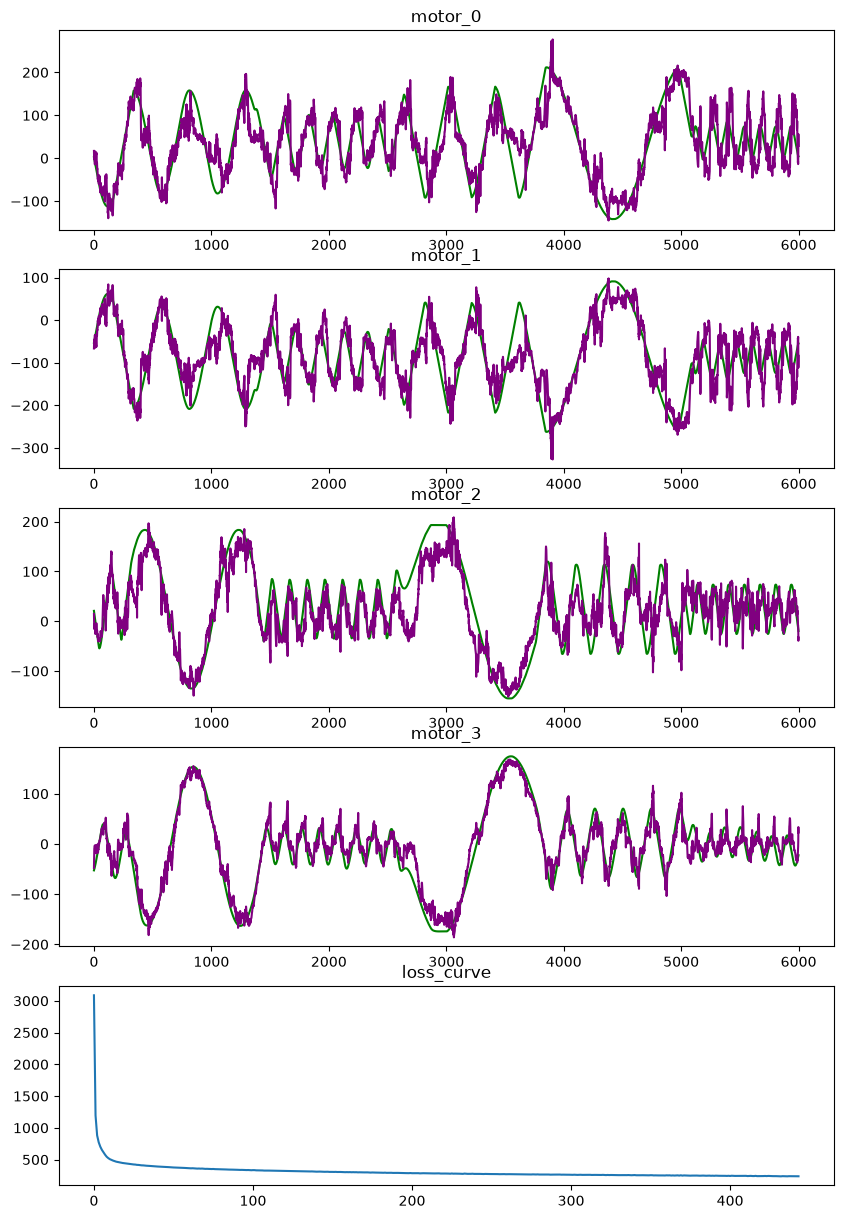

In [192]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Mean Squared Error:", mean_squared_error(Y_test, Y_pred))
print("Mean Absolute Error:", mean_absolute_error(Y_test, Y_pred))
print("R^2 Score:", r2_score(Y_test, Y_pred)) 

fig, ax = plt.subplots(5,1,figsize=(10,15))
ax[0].plot(Y_test[:, 0][:6000], label='Actual', color='green')
ax[0].plot(Y_pred[:, 0][:6000], label='Prediction', color='purple')
ax[0].set_title("motor_0")
ax[1].plot(Y_test[:, 1][:6000], label='Actual', color='green')
ax[1].plot(Y_pred[:, 1][:6000], label='Prediction', color='purple')
ax[1].set_title("motor_1")
ax[2].plot(Y_test[:, 2][:6000], label='Actual', color='green')
ax[2].plot(Y_pred[:, 2][:6000], label='Prediction', color='purple')
ax[2].set_title("motor_2")
ax[3].plot(Y_test[:, 3][:6000], label='Actual', color='green')
ax[3].plot(Y_pred[:, 3][:6000], label='Prediction', color='purple')
ax[3].set_title("motor_3")
ax[4].plot(model.loss_curve_)
ax[4].set_title("loss_curve")
plt.show()